In [12]:
import os
import numpy as np
import scipy.io as sp


nblab_path = os.environ["NBLAB_PATH"]

def get_loaded_beam():
    args = {'beam': 'parabolic', 'resolution': 256}
    beam_name = args["beam"]
    beam_resolution = args["resolution"]
    beam_file = sp.loadmat(f"{nblab_path}Beams/beam_data/{beam_name}_{beam_resolution}.mat")

    # zz_real = beam_file[f"parabolico_simetrico"].real
    # zz_imag = beam_file[f"parabolico_simetrico"].imag

    zz_real = beam_file[f"Haz_parabolico_{args['resolution']}"].real
    zz_imag = beam_file[f"Haz_parabolico_{args['resolution']}"].imag


    beam = zz_real + zz_imag * 1j
    beam_phase = np.angle(beam).astype("float64")
    beam_intensity = np.abs(beam)**2
    beam_intensity /= np.sum(np.sum(beam_intensity))
    beam_intensity = beam_intensity.astype("float64")
    return (beam_intensity, beam)



In [13]:
parabolic_beam = get_loaded_beam()[0]
beam = get_loaded_beam()[1]


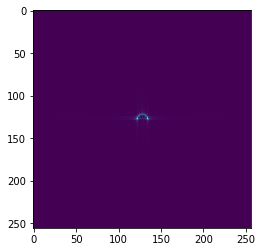

In [14]:
# Visualize the Fourier transform of the beam


import matplotlib.pyplot as plt
plt.imshow(np.fft.fftshift(np.abs(np.fft.fft2(beam))))
plt.show()


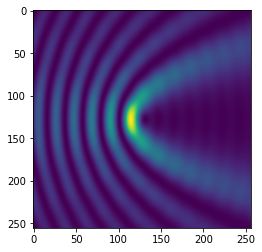

In [15]:
# Visualize parabolic_beam as its a matrix
import matplotlib.pyplot as plt
plt.imshow(parabolic_beam)
plt.show()
    

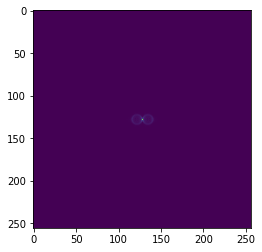

In [17]:
fourier_parabolic_beam = np.fft.fft2(parabolic_beam)
abs_fourier_parabolic_beam = np.fft.fftshift(np.abs(fourier_parabolic_beam))
plt.imshow(abs_fourier_parabolic_beam)


1e-05 20


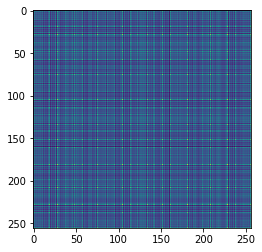

In [55]:
# Create a function that returns the angular spectrum of a plane wave
import numpy as np
import matplotlib.pyplot as plt

def angular_spectrum(args):
    wavelength = args["wavelength"]
    resolution = args["resolution"]
    size = args["size"]
    print(wavelength, size)
    k = 2 * np.pi / wavelength
    x = np.linspace(-size/2, size/2, resolution)
    y = np.linspace(-size/2, size/2, resolution)
    xx, yy = np.meshgrid(x, y)
    rr = np.sqrt(xx**2 + yy**2)
    plane_wave =  np.exp(1j * k * rr**2 )
    inverse_fourier_plane_wave = np.fft.ifft2(plane_wave)
    plane_wave = np.fft.fftshift(inverse_fourier_plane_wave)

    abs_plane_wave = np.abs(plane_wave)
    abs_plane_wave /= np.sum(np.sum(abs_plane_wave))
    return (abs_plane_wave, abs_plane_wave, abs_plane_wave)

# Use the angular_spectrum function to create a plane wave

args = {"wavelength": 0.00001, "resolution": 256, "size": 20}
plane_wave = angular_spectrum(args)[0]
plt.imshow(plane_wave)
plt.show()

